In [2]:
import pandas as pd
import numpy as np

In [ ]:
Revenue_Path = r'C:\Users\Usama Zubair\Projects\Financial Envelope\Data\Revenue\Ratios Analysis.xlsx'

In [4]:
revenue_data = pd.read_excel(Revenue_Path)

In [5]:
revenue_columns = ['Month-Year','Total Revenue', 'Gas Revenue', 'Condensate Revenue','Gas Processing Revenue','OPEX_Actual','Sales_Gas_BOE', 
       'Sales_Condensate', 'gas processing_actual', 'Total_sujawal_sales_BOE',
        'Sujjawal and gas processing', 'Revenue/BOE','Gas Revenue/BOE', 
       'Condensate/BOE', 'OPEX/BOE']

revenue_df =revenue_data[revenue_columns]
revenue_df =revenue_df.iloc[48:89]
#revenue_df = revenue_df.dropna(axis=0, how='all')
#revenue_df =  revenue_df[~revenue_df.drop(columns = ['Month-Year']).isna().all(axis=1)]

Feature Engineering

In [6]:
revenue_df['Month-Year'] = pd.to_datetime(revenue_df['Month-Year'])

# Set Month-Year as index
#revenue_df = revenue_df.set_index('Month-Year').sort_index()

# Define fiscal year (July–June)
def get_fy(date):
    return date.year + 1 if date.month >= 7 else date.year

revenue_df['FY'] = revenue_df['Month-Year'].map(get_fy)

# Cumulative sum per FY for each KPI
for col in ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']:
    revenue_df[f'{col}_FY_cumsum'] = revenue_df.groupby('FY')[col].cumsum()

# Create lag features
lags = [1, 2, 3]  # lag of 1, 2, 3 months
for col in ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']:
    for lag in lags:
        revenue_df[f'{col}_lag{lag}'] = revenue_df[col].shift(lag)

# Rolling sums
for col in ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']:
    revenue_df[f'{col}_roll2'] = revenue_df[col].rolling(window=2).sum()
    revenue_df[f'{col}_roll3'] = revenue_df[col].rolling(window=3).sum()

revenue_df['Month'] = revenue_df['Month-Year'].dt.month
revenue_df['Month_sin'] = np.sin(2 * np.pi * revenue_df['Month'] / 12)
revenue_df['Month_cos'] = np.cos(2 * np.pi * revenue_df['Month'] / 12)

revenue_df['Quarter'] = revenue_df['Month-Year'].dt.quarter
revenue_df['Year'] = revenue_df['Month-Year'].dt.year

for col in ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']:
     revenue_df[f'{col}_QoQ_sum'] = revenue_df.groupby(['Year', 'Quarter'])[col].transform('sum')


# Drop the original 'Month' column if desired
revenue_df = revenue_df.drop(columns=['Month'])




In [7]:
with pd.option_context("display.max_columns",None):
    print(revenue_df.head())

   Month-Year  Total Revenue  Gas Revenue  Condensate Revenue  \
48 2022-06-01    349483278.0  299943134.0          32781627.0   
49 2022-07-01    579619108.0  540121207.0          32571497.0   
50 2022-08-01    138836932.0   94867862.0          32724273.0   
51 2022-09-01    394340336.0  389777351.0          13128653.0   
52 2022-10-01    332839113.0  309529035.0          23310078.0   

    Gas Processing Revenue  OPEX_Actual  Sales_Gas_BOE  Sales_Condensate  \
48              16758517.0  83486233.80   36783.397182         1635.3505   
49               6926404.0  27282647.28   36235.858534         1635.3505   
50              11244797.0  54345612.58   33527.641892         1962.4206   
51              -8565668.0  50777616.51   30007.190311         1635.3505   
52                     NaN  52429567.48   30521.854666         1308.2804   

    gas processing_actual  Total_sujawal_sales_BOE  \
48           12871.320016             38418.747682   
49            9152.858713             37871.

In [8]:
with pd.option_context('display.max_columns',None):
    print(revenue_df.corr())

                                  Month-Year  Total Revenue  Gas Revenue  \
Month-Year                          1.000000      -0.489311    -0.814986   
Total Revenue                      -0.489311       1.000000     0.726642   
Gas Revenue                        -0.814986       0.726642     1.000000   
Condensate Revenue                 -0.144380       0.294224     0.038409   
Gas Processing Revenue              0.730407       0.075137    -0.620003   
OPEX_Actual                         0.268916      -0.235865    -0.306672   
Sales_Gas_BOE                      -0.680583       0.315141     0.465014   
Sales_Condensate                   -0.185276       0.192974     0.016569   
gas processing_actual               0.930488      -0.259365    -0.593342   
Total_sujawal_sales_BOE            -0.663391       0.314149     0.446754   
Sujjawal and gas processing         0.664844      -0.079452    -0.129435   
Revenue/BOE                         0.009173       0.149977     0.078039   
Gas Revenue/

In [9]:
revenue_df = revenue_df.reset_index(drop=True)
revenue_df.columns

Index(['Month-Year', 'Total Revenue', 'Gas Revenue', 'Condensate Revenue',
       'Gas Processing Revenue', 'OPEX_Actual', 'Sales_Gas_BOE',
       'Sales_Condensate', 'gas processing_actual', 'Total_sujawal_sales_BOE',
       'Sujjawal and gas processing', 'Revenue/BOE', 'Gas Revenue/BOE',
       'Condensate/BOE', 'OPEX/BOE', 'FY', 'Gas Revenue_FY_cumsum',
       'Condensate Revenue_FY_cumsum', 'Gas Processing Revenue_FY_cumsum',
       'Gas Revenue_lag1', 'Gas Revenue_lag2', 'Gas Revenue_lag3',
       'Condensate Revenue_lag1', 'Condensate Revenue_lag2',
       'Condensate Revenue_lag3', 'Gas Processing Revenue_lag1',
       'Gas Processing Revenue_lag2', 'Gas Processing Revenue_lag3',
       'Gas Revenue_roll2', 'Gas Revenue_roll3', 'Condensate Revenue_roll2',
       'Condensate Revenue_roll3', 'Gas Processing Revenue_roll2',
       'Gas Processing Revenue_roll3', 'Month_sin', 'Month_cos', 'Quarter',
       'Year', 'Gas Revenue_QoQ_sum', 'Condensate Revenue_QoQ_sum',
       'Gas Proc

In [9]:
gas_revenue_columns = ['Month-Year','Total Revenue', 'Gas Revenue','OPEX_Actual', 'Sales_Gas_BOE','Total_sujawal_sales_BOE',
                       'Revenue/BOE', 'Gas Revenue/BOE','Gas Revenue_FY_cumsum','Gas Revenue_lag2',
                       'Gas Revenue_roll3','Gas Revenue_QoQ_sum']
gas_revenue = revenue_df[gas_revenue_columns]

In [10]:
from statsmodels.tsa.stattools import adfuller
gas_revenue['Gas Revenue diff1'] = gas_revenue['Gas Revenue'].diff()
y = gas_revenue['Gas Revenue diff1'].dropna()

result = adfuller(y)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -18.293023006968337
p-value: 2.2951615711317598e-30
Critical Value (1%): -3.610399601308181
Critical Value (5%): -2.939108945868946
Critical Value (10%): -2.6080629651545038


C:\Users\uzubair\AppData\Local\Temp\ipykernel_512608\3348770856.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gas_revenue['Gas Revenue diff1'] = gas_revenue['Gas Revenue'].diff()


In [11]:
gas_revenue = gas_revenue.sort_values('Month-Year')

# Create the time series
ts = gas_revenue.set_index('Month-Year')['Gas Revenue']

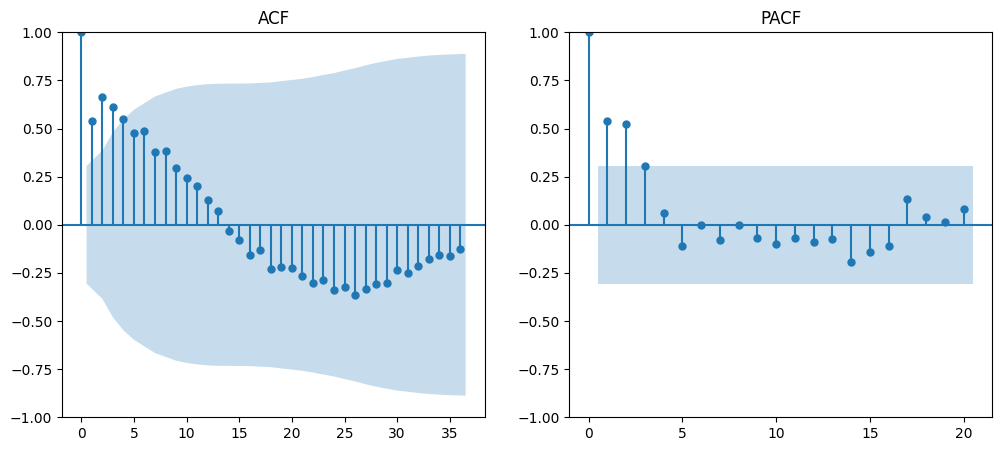

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ts: your Gas Revenue series
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(ts, lags=36, ax=plt.gca())  # lags=3 years for monthly data
plt.title('ACF')

n_obs = len(ts)
max_lag = n_obs // 2

plt.subplot(1,2,2)
plot_pacf(ts, lags=max_lag, ax=plt.gca())
plt.title('PACF')

plt.show()


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Example starting SARIMA parameters
import numpy as np

ts_log = np.log(ts)
model = SARIMAX(ts_log, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

forecast_log = model_fit.get_forecast(steps=24).predicted_mean
forecast = np.exp(forecast_log)  # back to original scale


C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8

MAE   : 11,783,833.72
RMSE  : 13,522,662.40
MAPE  : 11.35%
sMAPE : 12.14%


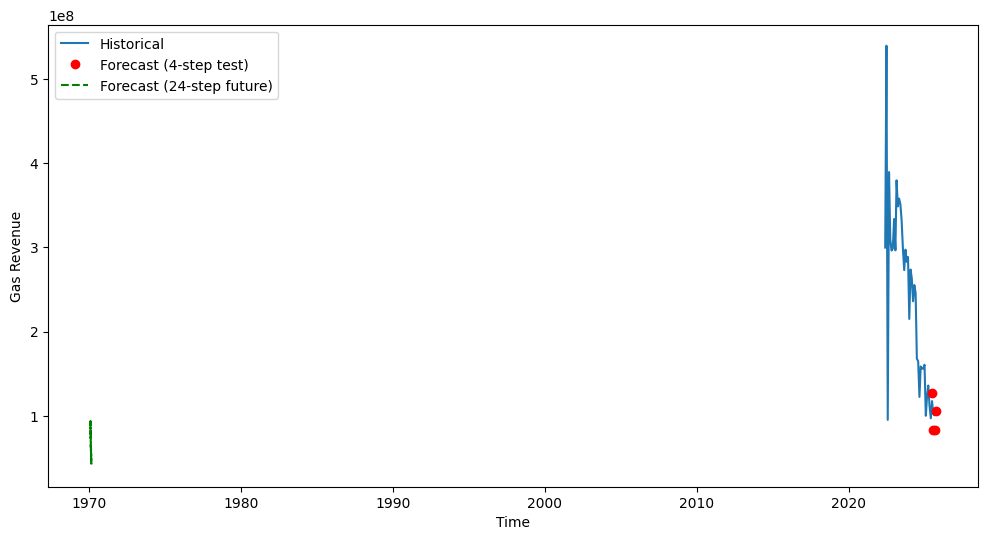

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# ts is your historical Gas Revenue series

# --- 1) Accuracy on last 4 months ---
train_acc = ts[:-4]
test_acc = ts[-4:]

# Fit SARIMA for accuracy
ts_log_train = np.log(train_acc)
model_acc = SARIMAX(ts_log_train, order=(1,1,1), seasonal_order=(1,1,1,3))
model_fit_acc = model_acc.fit(disp=False)

# Forecast next 4 months for accuracy
forecast_log_acc = model_fit_acc.get_forecast(steps=len(test_acc)).predicted_mean
forecast_acc = np.exp(forecast_log_acc)

# Accuracy metrics
mae = mean_absolute_error(test_acc, forecast_acc)
rmse = np.sqrt(mean_squared_error(test_acc, forecast_acc))
mape = np.mean(np.abs((test_acc - forecast_acc)/test_acc)) * 100
smape = 100 * np.mean(np.abs(forecast_acc - test_acc) / ((np.abs(test_acc) + np.abs(forecast_acc))/2))

print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# --- 2) Forecast next 24 months for visualization ---
ts_log_full = np.log(ts)
model_full = SARIMAX(ts_log_full, order=(1,1,1), seasonal_order=(1,1,1,3))
model_fit_full = model_full.fit(disp=False)

forecast_log_24 = model_fit_full.get_forecast(steps=24).predicted_mean
forecast_24 = np.exp(forecast_log_24)

# Plot
plt.figure(figsize=(12,6))
plt.plot(ts.index, ts, label='Historical')
plt.plot(ts.index[-4:], forecast_acc, 'ro', label='Forecast (4-step test)')
plt.plot(np.arange(len(ts), len(ts)+24), forecast_24, 'g--', label='Forecast (24-step future)')
plt.xlabel('Time')
plt.ylabel('Gas Revenue')
plt.legend()
plt.show()


# Exogenous Columns 

In [15]:
gas_revenue.columns

Index(['Month-Year', 'Total Revenue', 'Gas Revenue', 'OPEX_Actual',
       'Sales_Gas_BOE', 'Total_sujawal_sales_BOE', 'Revenue/BOE',
       'Gas Revenue/BOE', 'Gas Revenue_FY_cumsum', 'Gas Revenue_lag2',
       'Gas Revenue_roll3', 'Gas Revenue_QoQ_sum', 'Gas Revenue diff1'],
      dtype='object')

In [16]:
gas_revenue = gas_revenue.dropna()
gas_revenue = gas_revenue.set_index('Month-Year')
gas_revenue.tail()

,Total Revenue,Gas Revenue,OPEX_Actual,Sales_Gas_BOE,Total_sujawal_sales_BOE,Revenue/BOE,Gas Revenue/BOE,Gas Revenue_FY_cumsum,Gas Revenue_lag2,Gas Revenue_roll3,Gas Revenue_QoQ_sum,Gas Revenue diff1
Month-Year,,,,,,,,,,,,
2025-04-01,1.706794e+08,135687226.0,1.269152e+08,12943.565062,13547.385062,12598.696627,10482.987133,1.442381e+09,99734822.0,357117890.0,344548784.0,13991384.0
2025-05-01,2.823313e+08,112102594.0,1.004073e+08,16228.573272,17436.213272,16192.239171,6907.729479,1.554483e+09,121695842.0,369485662.0,344548784.0,-23584632.0
2025-06-01,2.655783e+08,96758964.0,7.150147e+07,14517.856963,15725.496963,16888.388047,6664.824171,1.651242e+09,135687226.0,344548784.0,344548784.0,-15343630.0
2025-07-01,2.413291e+08,117206898.0,8.016821e+07,15196.749269,17008.209269,14188.978770,7712.629585,1.172069e+08,112102594.0,326068456.0,318878320.0,20447934.0
2025-08-01,1.842436e+08,101319956.0,6.757702e+07,15222.342100,16731.892100,11011.519529,6656.003086,2.185269e+08,96758964.0,315285818.0,318878320.0,-15886942.0


# Model Selected for gas Revenue

In [17]:
exog_cols = [
       'Sales_Gas_BOE']

target = gas_revenue['Gas Revenue']
exog = gas_revenue[exog_cols]

exog = exog

# Train–test split
train_y = target[:-5]
test_y = target[-5:]

train_X = exog[:-5]
test_X = exog[-5:]

y_log_train = np.log(train_y)


model_gas_revenue = SARIMAX(
    y_log_train,
    exog=train_X,
    order=(0,1,0),
    seasonal_order=(1,1,1,3),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_gas_revenue = model_gas_revenue.fit(disp=False)

# Forecast for Accuracy

forecast_log_revenue = model_fit_gas_revenue.get_forecast(
    steps=len(test_y),
    exog=test_X
).predicted_mean

forecast_rev = np.exp(forecast_log_revenue)

mae = mean_absolute_error(test_y, forecast_rev)
rmse = np.sqrt(mean_squared_error(test_y, forecast_rev))
mape = np.mean(np.abs((test_y - forecast_rev) / test_y)) * 100
smape = 100 * np.mean(
    np.abs(forecast_rev - test_y) /
    ((np.abs(test_y) + np.abs(forecast_rev)) / 2)
    
)

# Total % difference
total_diff_pct = ((forecast_rev.sum() - test_y.sum()) / test_y.sum()) * 100  

print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"Total % Difference: {total_diff_pct:.2f}%")

MAE   : 7,111,608.76
RMSE  : 9,063,292.98
MAPE  : 6.67%
sMAPE : 6.52%
Total % Difference: -0.53%


C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [18]:
metric_df = pd.DataFrame({
    'KPI Name': ['Gas Revenue'],
    'Actual Value': [test_y.sum()],
    'Forecast Value': [forecast_rev.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [total_diff_pct]
})

metric_df


,KPI Name,Actual Value,Forecast Value,MAE,RMSE,MAPE,sMAPE,Pct_diff
0,Gas Revenue,563075638.0,5.601099e+08,7.111609e+06,9.063293e+06,6.67059,6.52013,-0.5267


In [51]:
exog.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37 entries, 2022-08-01 to 2025-08-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales_Gas_BOE  37 non-null     float64
dtypes: float64(1)
memory usage: 592.0 bytes


In [66]:
forecast_241 = forecast_24.to_frame(name='Sales_Gas_BOE')
forecast_241

,Sales_Gas_BOE
2025-11-01,13815.154505
2025-12-01,14890.789372
2026-01-01,12287.787910
2026-02-01,14511.725596
2026-03-01,12595.659184
2026-04-01,12689.339280
2026-05-01,12381.342865
2026-06-01,12965.454638
2026-07-01,10854.550435
2026-08-01,12698.399562


In [67]:
forecast_ahead_24 = model_fit_gas_revenue.get_forecast( steps=24,
    exog=forecast_241
).predicted_mean
forecast_ahead_24 = np.exp(forecast_ahead_24)
forecast_ahead_24

2025-06-01    1.137789e+08
2025-07-01    1.200751e+08
2025-08-01    9.202681e+07
2025-09-01    1.006427e+08
2025-10-01    1.063143e+08
2025-11-01    8.352839e+07
2025-12-01    8.906470e+07
2026-01-01    9.455122e+07
2026-02-01    7.342170e+07
2026-03-01    7.922018e+07
2026-04-01    8.359931e+07
2026-05-01    6.543307e+07
2026-06-01    7.005638e+07
2026-07-01    7.436931e+07
2026-08-01    5.787473e+07
2026-09-01    6.231439e+07
2026-10-01    6.581105e+07
2026-11-01    5.147977e+07
2026-12-01    5.515413e+07
2027-01-01    5.852523e+07
2027-02-01    4.559236e+07
2027-03-01    4.904317e+07
2027-04-01    5.183413e+07
2027-05-01    4.053753e+07
Freq: MS, Name: predicted_mean, dtype: float64

# Model For COndensate Revenue

In [19]:
revenue_df.columns

Index(['Month-Year', 'Total Revenue', 'Gas Revenue', 'Condensate Revenue',
       'Gas Processing Revenue', 'OPEX_Actual', 'Sales_Gas_BOE',
       'Sales_Condensate', 'gas processing_actual', 'Total_sujawal_sales_BOE',
       'Sujjawal and gas processing', 'Revenue/BOE', 'Gas Revenue/BOE',
       'Condensate/BOE', 'OPEX/BOE', 'FY', 'Gas Revenue_FY_cumsum',
       'Condensate Revenue_FY_cumsum', 'Gas Processing Revenue_FY_cumsum',
       'Gas Revenue_lag1', 'Gas Revenue_lag2', 'Gas Revenue_lag3',
       'Condensate Revenue_lag1', 'Condensate Revenue_lag2',
       'Condensate Revenue_lag3', 'Gas Processing Revenue_lag1',
       'Gas Processing Revenue_lag2', 'Gas Processing Revenue_lag3',
       'Gas Revenue_roll2', 'Gas Revenue_roll3', 'Condensate Revenue_roll2',
       'Condensate Revenue_roll3', 'Gas Processing Revenue_roll2',
       'Gas Processing Revenue_roll3', 'Month_sin', 'Month_cos', 'Quarter',
       'Year', 'Gas Revenue_QoQ_sum', 'Condensate Revenue_QoQ_sum',
       'Gas Proc

In [20]:
condensate_revenue = revenue_df[['Month-Year','Condensate Revenue','Sales_Condensate']]

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 0) Define target and exogenous variable
# -----------------------------
exog_cols = ['Sales_Condensate']

target = condensate_revenue['Condensate Revenue']
exog = condensate_revenue[exog_cols]

# -----------------------------
# 1) Train–test split
# -----------------------------
train_y = target[:-5]
test_y = target[-5:]

train_X = exog[:-5]
test_X = exog[-5:]

# -----------------------------
# 2) Fit SARIMAX model on raw values
# -----------------------------
model_condensate = SARIMAX(
    train_y,
    exog=train_X,
    order=(0,0,0),
    seasonal_order=(0,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_condensate = model_condensate.fit(disp=False)

# -----------------------------
# 3) Forecast for Accuracy
# -----------------------------
forecast_condensate = model_fit_condensate.get_forecast(
    steps=len(test_y),
    exog=test_X
).predicted_mean

forecast_condensate.index = test_y.index  # align indices

# -----------------------------
# 4) Accuracy metrics
# -----------------------------
mae = mean_absolute_error(test_y, forecast_condensate)
rmse = np.sqrt(mean_squared_error(test_y, forecast_condensate))
mape = np.mean(np.abs((test_y - forecast_condensate) / test_y)) * 100
smape = 100 * np.mean(
    np.abs(forecast_condensate - test_y) /
    ((np.abs(test_y) + np.abs(forecast_condensate)) / 2)
)

total_diff_pct = (forecast_condensate.sum() - test_y.sum()) / test_y.sum() * 100


print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"Percentage Diff (Total) : {total_diff_pct:.2f}%")

MAE   : 4,999,932.56
RMSE  : 6,983,835.24
MAPE  : 72.08%
sMAPE : 33.08%
Percentage Diff (Total) : 10.24%


In [22]:
metric_df_cond = pd.DataFrame({
    'KPI Name': ['Condensate Revenue'],
    'Actual Value': [test_y.sum()],
    'Forecast Value': [forecast_condensate.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [total_diff_pct]
})

metric_df_cond


,KPI Name,Actual Value,Forecast Value,MAE,RMSE,MAPE,sMAPE,Pct_diff
0,Condensate Revenue,1.045304e+08,1.152311e+08,4.999933e+06,6.983835e+06,72.082464,33.076481,10.236911


In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 0) Prepare target and exogenous variable
# -----------------------------
exog_cols = ['Sales_Condensate']

target = condensate_revenue['Condensate Revenue']
exog = condensate_revenue[exog_cols]

# Train–test split
train_y = target[:-5]
test_y = target[-5:]

train_X = exog[:-5]
test_X = exog[-5:]

# -----------------------------
# 1) Grid search for best SARIMAX parameters
# -----------------------------
p = d = q = range(0, 2)        # AR, I, MA orders
P = D = Q = range(0, 2)        # Seasonal orders
s = [3]                        # Seasonal period (quarterly example)

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for i in p:
    for j in d:
        for k in q:
            for I in P:
                for J in D:
                    for K in Q:
                        for seasonal_period in s:
                            try:
                                model = SARIMAX(
                                    train_y,
                                    exog=train_X,
                                    order=(i,j,k),
                                    seasonal_order=(I,J,K,seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                )
                                model_fit = model.fit(disp=False)
                                if model_fit.aic < best_aic:
                                    best_aic = model_fit.aic
                                    best_order = (i,j,k)
                                    best_seasonal_order = (I,J,K,seasonal_period)
                                    best_model = model_fit
                            except:
                                continue

print(f"Best SARIMAX order: {best_order}")
print(f"Best seasonal_order: {best_seasonal_order}")
print(f"Best AIC: {best_aic:.2f}")

# -----------------------------
# 2) Forecast for test period
# -----------------------------
forecast_condensate = best_model.get_forecast(steps=len(test_y), exog=test_X).predicted_mean
forecast_condensate.index = test_y.index  # align indices

# -----------------------------
# 3) Accuracy metrics
# -----------------------------
mae = mean_absolute_error(test_y, forecast_condensate)
rmse = np.sqrt(mean_squared_error(test_y, forecast_condensate))
mape = np.mean(np.abs((test_y - forecast_condensate)/test_y)) * 100
smape = 100 * np.mean(np.abs(forecast_condensate - test_y) / ((np.abs(test_y) + np.abs(forecast_condensate))/2))

# Total % difference
total_actual = test_y.sum()
total_forecast = forecast_condensate.sum()
total_diff_pct = ((total_forecast - total_actual)/total_actual) * 100

print(f"MAE               : {mae:,.2f}")
print(f"RMSE              : {rmse:,.2f}")
print(f"MAPE              : {mape:.2f}%")
print(f"sMAPE             : {smape:.2f}%")
print(f"Total % Difference: {total_diff_pct:.2f}%")


Best SARIMAX order: (0, 1, 1)
Best seasonal_order: (1, 1, 1, 3)
Best AIC: 979.68
MAE               : 51,993,469.01
RMSE              : 53,813,532.83
MAPE              : 484.90%
sMAPE             : 173.45%
Total % Difference: -18.09%


# Gas Processing Revenue Forecasting

In [23]:
revenue_df.columns

Index(['Month-Year', 'Total Revenue', 'Gas Revenue', 'Condensate Revenue',
       'Gas Processing Revenue', 'OPEX_Actual', 'Sales_Gas_BOE',
       'Sales_Condensate', 'gas processing_actual', 'Total_sujawal_sales_BOE',
       'Sujjawal and gas processing', 'Revenue/BOE', 'Gas Revenue/BOE',
       'Condensate/BOE', 'OPEX/BOE', 'FY', 'Gas Revenue_FY_cumsum',
       'Condensate Revenue_FY_cumsum', 'Gas Processing Revenue_FY_cumsum',
       'Gas Revenue_lag1', 'Gas Revenue_lag2', 'Gas Revenue_lag3',
       'Condensate Revenue_lag1', 'Condensate Revenue_lag2',
       'Condensate Revenue_lag3', 'Gas Processing Revenue_lag1',
       'Gas Processing Revenue_lag2', 'Gas Processing Revenue_lag3',
       'Gas Revenue_roll2', 'Gas Revenue_roll3', 'Condensate Revenue_roll2',
       'Condensate Revenue_roll3', 'Gas Processing Revenue_roll2',
       'Gas Processing Revenue_roll3', 'Month_sin', 'Month_cos', 'Quarter',
       'Year', 'Gas Revenue_QoQ_sum', 'Condensate Revenue_QoQ_sum',
       'Gas Proc

In [24]:
gas_processing_revenue = revenue_df[['Month-Year','Gas Processing Revenue']]

In [25]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 0) Prepare the data
# -----------------------------
gas_processing_revenue['Month-Year'] = pd.to_datetime(gas_processing_revenue['Month-Year'])
gas_processing_revenue = gas_processing_revenue.set_index('Month-Year').sort_index()

target = gas_processing_revenue['Gas Processing Revenue']

# -----------------------------
# 1) Train-test split
# -----------------------------
train_y = target[-9:-3]  # last 6 rows for training
test_y  = target[-3:]     # last 3 rows for testing

# -----------------------------
# 2) Fit SARIMAX model (no exogenous)
# -----------------------------
model_gas = SARIMAX(
    train_y,
    order=(1,1,1),          # ARIMA(p,d,q)
    seasonal_order=(1,1,1,12),  # seasonal order
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_gas = model_gas.fit(disp=False)

# -----------------------------
# 3) Forecast
# -----------------------------
forecast_gas = model_fit_gas.get_forecast(steps=len(test_y)).predicted_mean
forecast_gas.index = test_y.index  # align index

# -----------------------------
# 4) Accuracy metrics
# -----------------------------
mae  = mean_absolute_error(test_y, forecast_gas)
rmse = np.sqrt(mean_squared_error(test_y, forecast_gas))
mape = np.mean(np.abs((test_y - forecast_gas) / test_y)) * 100
smape = 100 * np.mean(np.abs(forecast_gas - test_y) / ((np.abs(test_y) + np.abs(forecast_gas)) / 2))
total_diff_pct = (forecast_gas.sum() - test_y.sum()) / test_y.sum() * 100

# Print metrics
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"Pct Diff (Total) : {total_diff_pct:.2f}%")


MAE   : 108,194,544.00
RMSE  : 146,731,073.94
MAPE  : 52.41%
sMAPE : 64.59%
Pct Diff (Total) : -48.07%


C:\Users\uzubair\AppData\Local\Temp\ipykernel_512608\1744211344.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gas_processing_revenue['Month-Year'] = pd.to_datetime(gas_processing_revenue['Month-Year'])
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred

In [26]:
import pandas as pd

# Create a DataFrame with metrics
metric_df_process = pd.DataFrame({
    'KPI Name': ['Gas Processing Revenue'],
    'Actual Value': [test_y.sum()],
    'Forecast Value': [forecast_gas.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [total_diff_pct]
})

print(metric_df_process)


                 KPI Name  Actual Value  Forecast Value          MAE  \
0  Gas Processing Revenue   540937467.0     280891011.0  108194544.0   

           RMSE       MAPE      sMAPE   Pct_diff  
0  1.467311e+08  52.407907  64.588937 -48.073293  


In [27]:
metric_df_process

,KPI Name,Actual Value,Forecast Value,MAE,RMSE,MAPE,sMAPE,Pct_diff
0,Gas Processing Revenue,540937467.0,280891011.0,108194544.0,1.467311e+08,52.407907,64.588937,-48.073293


In [88]:
# -----------------------------
# 5) Forecast next 24 steps
# -----------------------------
forecast_24 = model_fit_gas.get_forecast(steps=24).predicted_mean

# Create proper datetime index for the next 24 months
last_date = train_y.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')

forecast_24.index = forecast_index

# Display forecast
print(forecast_24)


2025-08-01    9.363034e+07
2025-09-01    9.363034e+07
2025-10-01    9.363034e+07
2025-11-01    9.363034e+07
2025-12-01    9.363034e+07
2026-01-01    9.363034e+07
2026-02-01    2.089088e+08
2026-03-01    1.332863e+08
2026-04-01    1.122118e+08
2026-05-01    1.864991e+08
2026-06-01    2.002956e+08
2026-07-01    1.296214e+08
2026-08-01    1.296214e+08
2026-09-01    1.296214e+08
2026-10-01    1.296214e+08
2026-11-01    1.296214e+08
2026-12-01    1.296214e+08
2027-01-01    1.296214e+08
2027-02-01    2.448999e+08
2027-03-01    1.692774e+08
2027-04-01    1.482029e+08
2027-05-01    2.224902e+08
2027-06-01    2.362867e+08
2027-07-01    1.656125e+08
Freq: MS, Name: predicted_mean, dtype: float64


In [81]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 0) Define parameter grid
# -----------------------------
p = d = q = range(0, 2)  # small range for example
P = D = Q = range(0, 2)
s = [2]  # assuming yearly seasonality

# Generate all combinations
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, s))

# -----------------------------
# 1) Train-test split
# -----------------------------
train_y = target[-9:-3]
test_y = target[-3:]

# -----------------------------
# 2) Iterate over all combinations to find best AIC
# -----------------------------
best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(
                train_y,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_fit = model.fit(disp=False)
            
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = order
                best_seasonal_order = seasonal_order
                best_model = model_fit
        except:
            continue

print(f"Best SARIMAX order: {best_order}, seasonal_order: {best_seasonal_order}, AIC: {best_aic:.2f}")

# -----------------------------
# 3) Forecast using best model
# -----------------------------
forecast_gas = best_model.get_forecast(steps=len(test_y)).predicted_mean
forecast_gas.index = test_y.index  # align index

# -----------------------------
# 4) Accuracy metrics
# -----------------------------
mae  = mean_absolute_error(test_y, forecast_gas)
rmse = np.sqrt(mean_squared_error(test_y, forecast_gas))
mape = np.mean(np.abs((test_y - forecast_gas) / test_y)) * 100
smape = 100 * np.mean(np.abs(forecast_gas - test_y) / ((np.abs(test_y) + np.abs(forecast_gas)) / 2))
total_diff_pct = (forecast_gas.sum() - test_y.sum()) / test_y.sum() * 100

print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"Pct Diff (Total) : {total_diff_pct:.2f}%")


Best SARIMAX order: (0, 1, 0), seasonal_order: (0, 1, 1, 2), AIC: 4.00
MAE   : 146,112,990.67
RMSE  : 185,109,790.77
MAPE  : 75.87%
sMAPE : 102.79%
Pct Diff (Total) : -64.00%


# Training Model for Gas Production Forecasting

In [10]:
revenue_df.columns
production_cols = ['Month-Year','Sales_Gas_BOE',
       'Sales_Condensate','gas processing_actual', 'Total_sujawal_sales_BOE',
       'Sujjawal and gas processing', 'Revenue/BOE', 'Gas Revenue/BOE',
       'Condensate/BOE', 'OPEX/BOE']
production_df = revenue_df[production_cols]

In [11]:
prod_forecasting_cols = ['Month-Year','Sales_Gas_BOE',
       'Sales_Condensate','gas processing_actual']
prod_forecasting_df = production_df[prod_forecasting_cols]

In [12]:
gas_prod = prod_forecasting_df.sort_values('Month-Year')

# Create the time series
ts = gas_prod.set_index('Month-Year')['Sales_Gas_BOE']
ts = ts.dropna()

C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8

MAE   : 1,745.11
RMSE  : 1,890.29
MAPE  : 11.71%
sMAPE : 12.58%


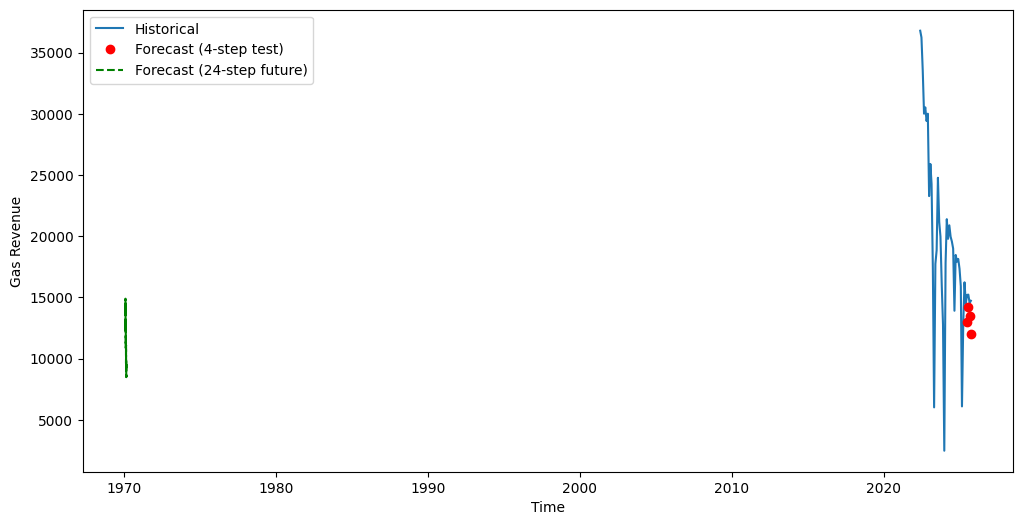

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# ts is your historical Gas Revenue series

# --- 1) Accuracy on last 4 months ---
train_acc = ts[:-4]
test_acc = ts[-4:]

# Fit SARIMA for accuracy
ts_log_train = np.log(train_acc)
model_acc = SARIMAX(ts_log_train, order=(0,1,0), seasonal_order=(0,1,1,3))
model_fit_acc = model_acc.fit(disp=False)

# Forecast next 4 months for accuracy
forecast_log_acc = model_fit_acc.get_forecast(steps=len(test_acc)).predicted_mean
forecast_acc = np.exp(forecast_log_acc)

# Accuracy metrics
mae = mean_absolute_error(test_acc, forecast_acc)
rmse = np.sqrt(mean_squared_error(test_acc, forecast_acc))
mape = np.mean(np.abs((test_acc - forecast_acc)/test_acc)) * 100
smape = 100 * np.mean(np.abs(forecast_acc - test_acc) / ((np.abs(test_acc) + np.abs(forecast_acc))/2))
pct_diff = (forecast_acc.sum() - test_acc.sum()) / test_acc.sum() * 100 
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")


# --- 2) Forecast next 24 months for visualization ---
ts_log_full = np.log(ts)
model_full = SARIMAX(ts_log_full, order=(1,1,1), seasonal_order=(1,1,1,3))
model_fit_full = model_full.fit(disp=False)

forecast_log_24 = model_fit_full.get_forecast(steps=24).predicted_mean
forecast_24 = np.exp(forecast_log_24)

# Plot
plt.figure(figsize=(12,6))
plt.plot(ts.index, ts, label='Historical')
plt.plot(ts.index[-4:], forecast_acc, 'ro', label='Forecast (4-step test)')
plt.plot(np.arange(len(ts), len(ts)+24), forecast_24, 'g--', label='Forecast (24-step future)')
plt.xlabel('Time')
plt.ylabel('Gas Revenue')
plt.legend()
plt.show()


In [20]:
gas_prod_forecast = pd.concat([test_acc,forecast_24],axis=0)
gas_prod_forecast

2025-07-01    15196.749269
2025-08-01    15222.342100
2025-09-01    14527.000000
2025-10-01    14722.000000
2025-11-01    13815.154505
2025-12-01    14890.789372
2026-01-01    12287.787910
2026-02-01    14511.725596
2026-03-01    12595.659184
2026-04-01    12689.339280
2026-05-01    12381.342865
2026-06-01    12965.454638
2026-07-01    10854.550435
2026-08-01    12698.399562
2026-09-01    11138.488541
2026-10-01    11085.008754
2026-11-01    10953.025311
2026-12-01    11331.513184
2027-01-01     9597.122770
2027-02-01    11102.051626
2027-03-01     9845.896935
2027-04-01     9693.548668
2027-05-01     9679.699362
2027-06-01     9911.528775
2027-07-01     8479.387962
2027-08-01     9713.067481
2027-09-01     8697.242719
2027-10-01     8482.635166
dtype: float64

In [32]:
import pandas as pd

# Create metric DataFrame
metric_df_gas_prod = pd.DataFrame({
    'KPI Name': ['Gas Revenue'],
    'Actual Value': [test_acc.sum()],
    'Forecast Value': [forecast_acc.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [pct_diff]
})

print(metric_df_gas_prod)


      KPI Name  Actual Value  Forecast Value          MAE         RMSE  \
0  Gas Revenue  59668.091369    52687.646747  1745.111155  1890.289156   

        MAPE      sMAPE  Pct_diff  
0  11.706499  12.579113 -11.69879  


# Condesate Production Model

In [22]:
gas_prod = prod_forecasting_df.sort_values('Month-Year')

# Create the time series
condensate_prod = gas_prod.set_index('Month-Year')['Sales_Condensate']
condensate_prod = condensate_prod.dropna()

C:\Users\uzubair\AppData\Local\Temp\ipykernel_16836\193730387.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  condensate_prod = condensate_prod.fillna(method='ffill')  # fill missing values


MAE   : 293.69
RMSE  : 342.82
MAPE  : 18.07%
sMAPE : 20.44%


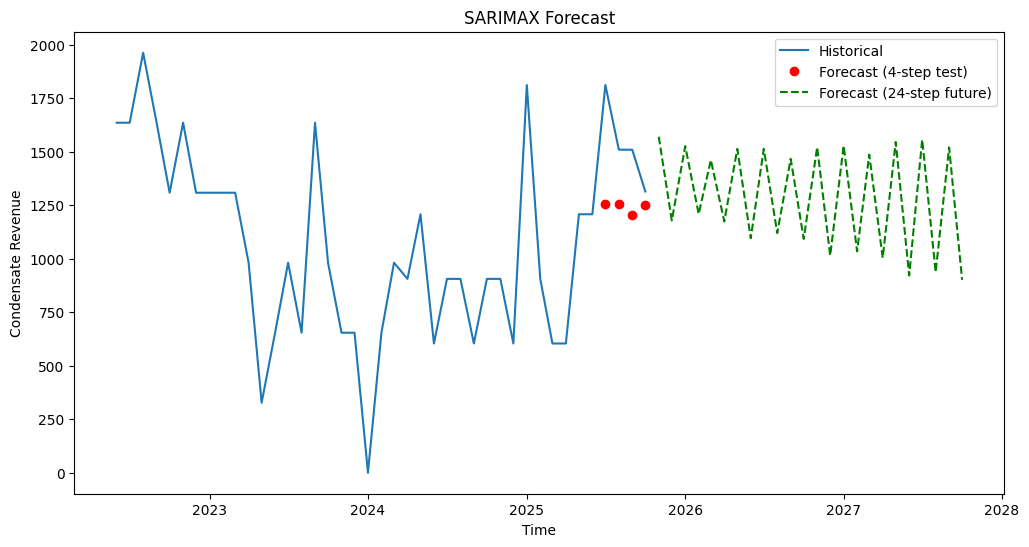

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# --- 0) Ensure datetime index ---
condensate_prod = condensate_prod.copy()
condensate_prod.index = pd.to_datetime(condensate_prod.index)
condensate_prod = condensate_prod.asfreq('MS')  # monthly start
condensate_prod = condensate_prod.fillna(method='ffill')  # fill missing values

# --- 1) Accuracy on last 4 months ---
train_cond = condensate_prod[:-4]
test_cond = condensate_prod[-4:]

# Fit SARIMAX on original values (no log)
model_cond = SARIMAX(train_cond, order=(0,1,0), seasonal_order=(0,1,1,3),
                     enforce_stationarity=False, enforce_invertibility=False)
model_fit_cond = model_cond.fit(disp=False)

# Forecast next 4 months for accuracy
forecast_cond = model_fit_cond.get_forecast(steps=len(test_cond)).predicted_mean
forecast_cond.index = test_cond.index  # align indices

# --- Accuracy metrics ---
mae = mean_absolute_error(test_cond, forecast_cond)
rmse = np.sqrt(mean_squared_error(test_cond, forecast_cond))
mape = np.mean(np.abs((test_cond - forecast_cond)/test_cond)) * 100
smape = 100 * np.mean(np.abs(forecast_cond - test_cond) / ((np.abs(test_cond) + np.abs(forecast_cond))/2))
pct_diff = (forecast_cond.sum() - test_cond.sum()) / test_acc.sum() * 100 
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# --- 2) Forecast next 24 months ---
model_full_cond = SARIMAX(condensate_prod, order=(1,1,1), seasonal_order=(1,1,1,3),
                          enforce_stationarity=False, enforce_invertibility=False)
model_fit_full = model_full_cond.fit(disp=False)

forecast_24_cond = model_fit_full.get_forecast(steps=24).predicted_mean

# Create proper future dates
last_date = condensate_prod.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=24, freq='MS')
forecast_24_cond = pd.Series(forecast_24_cond.values, index=forecast_dates)

# --- 3) Plot ---
plt.figure(figsize=(12,6))
plt.plot(condensate_prod.index, condensate_prod, label='Historical')
plt.plot(test_cond.index, forecast_cond, 'ro', label='Forecast (4-step test)')
plt.plot(forecast_24_cond.index, forecast_24_cond, 'g--', label='Forecast (24-step future)')
plt.xlabel('Time')
plt.ylabel('Condensate Revenue')
plt.title('SARIMAX Forecast')
plt.legend()
plt.show()


In [25]:
cond_prod_forecast = pd.concat([test_cond,forecast_24_cond],axis=0)
cond_prod_forecast

2025-07-01    1811.460000
2025-08-01    1509.550000
2025-09-01    1509.000000
2025-10-01    1314.000000
2025-11-01    1570.047397
2025-12-01    1178.649760
2026-01-01    1526.012928
2026-02-01    1208.624139
2026-03-01    1460.973766
2026-04-01    1174.083789
2026-05-01    1513.161774
2026-06-01    1095.618900
2026-07-01    1513.527727
2026-08-01    1119.683375
2026-09-01    1466.734051
2026-10-01    1092.463655
2026-11-01    1521.527502
2026-12-01    1014.364972
2027-01-01    1528.184328
2027-02-01    1034.485766
2027-03-01    1486.268355
2027-04-01    1003.891860
2027-05-01    1545.225755
2027-06-01     921.664938
2027-07-01    1556.601806
2027-08-01     937.049580
2027-09-01    1519.656962
2027-10-01     901.399862
Freq: MS, dtype: float64

In [44]:
import pandas as pd

# Create metric DataFrame
metric_df_cond_prod = pd.DataFrame({
    'KPI Name': ['Condensate Prod BOE'],
    'Actual Value': [test_cond.sum()],
    'Forecast Value': [forecast_cond.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [pct_diff]
})

print(metric_df_cond_prod)


              KPI Name  Actual Value  Forecast Value         MAE        RMSE  \
0  Condensate Prod BOE       6144.01     4969.230596  293.694851  342.822435   

        MAPE      sMAPE  Pct_diff  
0  18.070622  20.440556 -1.968857  


Best SARIMAX order: (1, 1, 1)
Best seasonal_order: (1, 1, 0, 8)
Best AIC: 285.01
MAE   : 458.84
RMSE  : 482.36
MAPE  : 29.36%
sMAPE : 33.50%


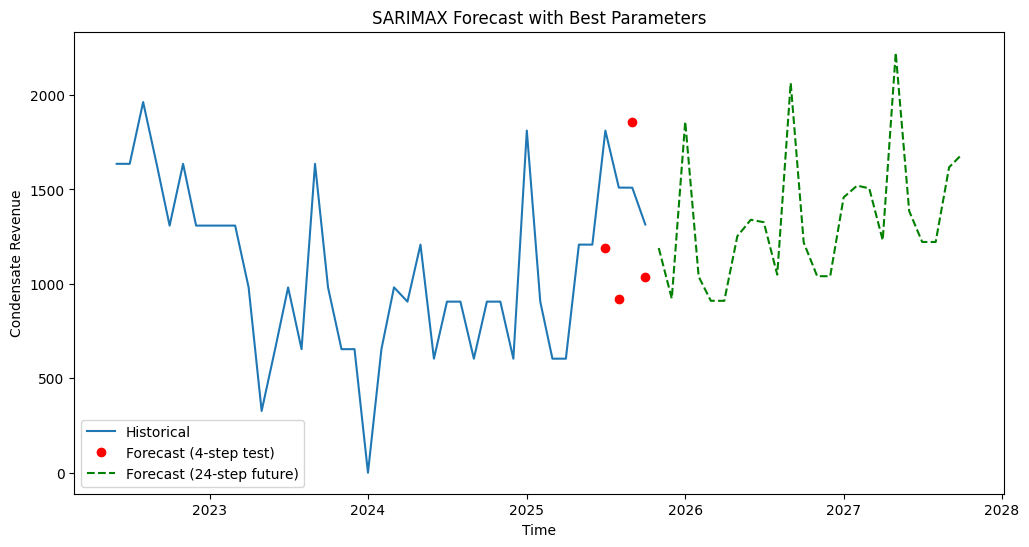

In [222]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# --- 0) Prepare series ---
condensate_prod = condensate_prod.copy()
condensate_prod.index = pd.to_datetime(condensate_prod.index)
condensate_prod = condensate_prod.asfreq('MS')
condensate_prod = condensate_prod.fillna(method='ffill')  # fill missing values

# --- 1) Train-test split ---
train_cond = condensate_prod[:-4]
test_cond = condensate_prod[-4:]

# --- 2) Grid search for best SARIMAX parameters ---
p = d = q = range(0, 2)  # AR, I, MA orders
P = D = Q = range(0, 2)  # seasonal orders
s = [3,4,2,8]            # seasonal periods (adjust as per your data)

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for i in p:
    for j in d:
        for k in q:
            for I in P:
                for J in D:
                    for K in Q:
                        for seasonal_period in s:
                            try:
                                model = SARIMAX(train_cond,
                                                order=(i,j,k),
                                                seasonal_order=(I,J,K,seasonal_period),
                                                enforce_stationarity=False,
                                                enforce_invertibility=False)
                                model_fit = model.fit(disp=False)
                                if model_fit.aic < best_aic:
                                    best_aic = model_fit.aic
                                    best_order = (i,j,k)
                                    best_seasonal_order = (I,J,K,seasonal_period)
                                    best_model = model_fit
                            except:
                                continue

print(f"Best SARIMAX order: {best_order}")
print(f"Best seasonal_order: {best_seasonal_order}")
print(f"Best AIC: {best_aic:.2f}")

# --- 3) Forecast 4-step test using best model ---
forecast_cond = best_model.get_forecast(steps=len(test_cond)).predicted_mean
forecast_cond.index = test_cond.index

# Accuracy metrics
mae = mean_absolute_error(test_cond, forecast_cond)
rmse = np.sqrt(mean_squared_error(test_cond, forecast_cond))
mape = np.mean(np.abs((test_cond - forecast_cond)/test_cond)) * 100
smape = 100 * np.mean(np.abs(forecast_cond - test_cond) / ((np.abs(test_cond) + np.abs(forecast_cond))/2))

print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# --- 4) Forecast next 24 months ---
forecast_24_cond = best_model.get_forecast(steps=24).predicted_mean
last_date = condensate_prod.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=24, freq='MS')
forecast_24_cond = pd.Series(forecast_24_cond.values, index=forecast_dates)

# --- 5) Plot ---
plt.figure(figsize=(12,6))
plt.plot(condensate_prod.index, condensate_prod, label='Historical')
plt.plot(test_cond.index, forecast_cond, 'ro', label='Forecast (4-step test)')
plt.plot(forecast_24_cond.index, forecast_24_cond, 'g--', label='Forecast (24-step future)')
plt.xlabel('Time')
plt.ylabel('Condensate Revenue')
plt.title('SARIMAX Forecast with Best Parameters')
plt.legend()
plt.show()


# Gas Processing Model

In [26]:
gas_prod.columns

Index(['Month-Year', 'Sales_Gas_BOE', 'Sales_Condensate',
       'gas processing_actual'],
      dtype='object')

In [27]:
gas_prod = prod_forecasting_df.sort_values('Month-Year')

# Create the time series
gas_process_prod = gas_prod.set_index('Month-Year')['gas processing_actual']


In [30]:
#Take the last 9 rows
gas_last9 = gas_process_prod[-9:]

# Split into training (6 rows) and testing (3 rows)
train_y = gas_last9[:5]
test_y  = gas_last9[5:]

# -----------------------------
# 1) Fit SARIMAX model (no exogenous)
# -----------------------------
model_gas = SARIMAX(
    train_y,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),  # adjust if seasonal period is different
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_gas = model_gas.fit(disp=False)

# -----------------------------
# 2) Forecast on test data
# -----------------------------
forecast_gas = model_fit_gas.get_forecast(steps=len(test_y)).predicted_mean
forecast_gas.index = test_y.index  # align index

# -----------------------------
# 3) Accuracy metrics
# -----------------------------
mae  = mean_absolute_error(test_y, forecast_gas)
rmse = np.sqrt(mean_squared_error(test_y, forecast_gas))
mape = np.mean(np.abs((test_y - forecast_gas) / test_y)) * 100
smape = 100 * np.mean(np.abs(forecast_gas - test_y) / ((np.abs(test_y) + np.abs(forecast_gas)) / 2))
pct_diff = (forecast_gas.sum() - test_y.sum()) / test_y.sum() * 100

# -----------------------------
# 4) Create metric DataFrame
# -----------------------------
metric_gas_processing = pd.DataFrame({
    'KPI Name': ['Gas Processing Actual'],
    'Actual Value': [test_y.sum()],
    'Forecast Value': [forecast_gas.sum()],
    'MAE': [mae],
    'RMSE': [rmse],
    'MAPE': [mape],
    'sMAPE': [smape],
    'Pct_diff': [pct_diff]
})

print(metric_gas_processing)

# -----------------------------
# 5) Forecast next 24 months (optional)
# -----------------------------
forecast_24 = model_fit_gas.get_forecast(steps=24).predicted_mean

# Create proper datetime index for the next 24 months
last_date = train_y.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
forecast_24.index = forecast_index

print("\nNext 24 months forecast:")
print(forecast_24)

                KPI Name  Actual Value  Forecast Value     MAE         RMSE  \
0  Gas Processing Actual      374260.0        369396.0  5442.0  5756.561865   

       MAPE     sMAPE  Pct_diff  
0  5.952902  5.915238 -1.299631  

Next 24 months forecast:
2025-07-01     92349.000000
2025-08-01     92349.000000
2025-09-01     92349.000000
2025-10-01     92349.000000
2025-11-01     92349.000000
2025-12-01     92349.000000
2026-01-01     92349.000000
2026-02-01    126777.149248
2026-03-01    125097.743752
2026-04-01    165780.925376
2026-05-01    171518.925376
2026-06-01    167483.925376
2026-07-01    167483.925376
2026-08-01    167483.925376
2026-09-01    167483.925376
2026-10-01    167483.925376
2026-11-01    167483.925376
2026-12-01    167483.925376
2027-01-01    167483.925376
2027-02-01    201912.074624
2027-03-01    200232.669128
2027-04-01    240915.850752
2027-05-01    246653.850752
2027-06-01    242618.850752
Freq: MS, Name: predicted_mean, dtype: float64


C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'

In [43]:
# cOMBINING THE fORECAST RESULTS

forecast_prod_combined = pd.DataFrame({'Gas Production': gas_prod_forecast,
                                       'condensate producrion': cond_prod_forecast,
                                       'gas processing production': forecast_24})
forecast_prod_combined.to_excel(r'D:\OneDrive - Octopus Digital\Subscription\ML Work\MPCL_FE\Model Development\Forecast Review with Mari\Novemeber forecast Analysis\Model Development\Data\production_forecast.xlsx')

In [40]:
gas_process_forecast = pd.concat([test_y,forecast_24],axis=0)
forecast_24

2025-07-01     92349.000000
2025-08-01     92349.000000
2025-09-01     92349.000000
2025-10-01     92349.000000
2025-11-01     92349.000000
2025-12-01     92349.000000
2026-01-01     92349.000000
2026-02-01    126777.149248
2026-03-01    125097.743752
2026-04-01    165780.925376
2026-05-01    171518.925376
2026-06-01    167483.925376
2026-07-01    167483.925376
2026-08-01    167483.925376
2026-09-01    167483.925376
2026-10-01    167483.925376
2026-11-01    167483.925376
2026-12-01    167483.925376
2027-01-01    167483.925376
2027-02-01    201912.074624
2027-03-01    200232.669128
2027-04-01    240915.850752
2027-05-01    246653.850752
2027-06-01    242618.850752
Freq: MS, Name: predicted_mean, dtype: float64

In [48]:
import pandas as pd

# Suppose you have multiple metric DataFrames
# e.g., metric_df1, metric_df2, metric_df3
all_metrics = pd.concat([metric_df, metric_df_cond,metric_df_process,metric_df_gas_prod,metric_df_cond_prod,metric_gas_processing], ignore_index=True)

print(all_metrics)


                 KPI Name  Actual Value  Forecast Value           MAE  \
0             Gas Revenue  5.630756e+08    5.601099e+08  7.111609e+06   
1      Condensate Revenue  1.045304e+08    1.152311e+08  4.999933e+06   
2  Gas Processing Revenue  5.409375e+08    2.808910e+08  1.081945e+08   
3             Gas Revenue  5.966809e+04    5.268765e+04  1.745111e+03   
4     Condensate Prod BOE  6.144010e+03    4.969231e+03  2.936949e+02   
5   Gas Processing Actual  2.768350e+05    2.922750e+05  5.146667e+03   

           RMSE       MAPE      sMAPE   Pct_diff  
0  9.063293e+06   6.670590   6.520130  -0.526700  
1  6.983835e+06  72.082464  33.076481  10.236911  
2  1.467311e+08  52.407907  64.588937 -48.073293  
3  1.890289e+03  11.706499  12.579113 -11.698790  
4  3.428224e+02  18.070622  20.440556  -1.968857  
5  7.878997e+03   6.040575   5.633741   5.577329  


In [49]:
all_metrics.to_excel(r'D:\OneDrive - Octopus Digital\Subscription\ML Work\MPCL_FE\Model Development\Forecast Review with Mari\Novemeber forecast Analysis\November forecast\DB Data Analysis\Actual Data Analysis\Metrices\revenue_metrices_15dec2025.xlsx')

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# --- 0) Ensure datetime index ---
condensate_prod = condensate_prod.copy()
condensate_prod.index = pd.to_datetime(condensate_prod.index)
condensate_prod = condensate_prod.asfreq('MS')  # monthly start
condensate_prod = condensate_prod.fillna(method='ffill')  # fill missing values

# --- 1) Accuracy on last 4 months ---
train_cond = condensate_prod[:-4]
test_cond = condensate_prod[-4:]

# Fit SARIMAX on original values (no log)
model_cond = SARIMAX(train_cond, order=(0,1,0), seasonal_order=(0,1,1,3),
                     enforce_stationarity=False, enforce_invertibility=False)
model_fit_cond = model_cond.fit(disp=False)

# Forecast next 4 months for accuracy
forecast_cond = model_fit_cond.get_forecast(steps=len(test_cond)).predicted_mean
forecast_cond.index = test_cond.index  # align indices

# --- Accuracy metrics ---
mae = mean_absolute_error(test_cond, forecast_cond)
rmse = np.sqrt(mean_squared_error(test_cond, forecast_cond))
mape = np.mean(np.abs((test_cond - forecast_cond)/test_cond)) * 100
smape = 100 * np.mean(np.abs(forecast_cond - test_cond) / ((np.abs(test_cond) + np.abs(forecast_cond))/2))
pct_diff = (forecast_acc.sum() - test_acc.sum()) / test_acc.sum() * 100 
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# --- 2) Forecast next 24 months ---
model_full_cond = SARIMAX(condensate_prod, order=(1,1,1), seasonal_order=(1,1,1,3),
                          enforce_stationarity=False, enforce_invertibility=False)
model_fit_full = model_full_cond.fit(disp=False)

forecast_24_cond = model_fit_full.get_forecast(steps=24).predicted_mean

# Create proper future dates
last_date = condensate_prod.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=24, freq='MS')
forecast_24_cond = pd.Series(forecast_24_cond.values, index=forecast_dates)

# --- 3) Plot ---
plt.figure(figsize=(12,6))
plt.plot(condensate_prod.index, condensate_prod, label='Historical')
plt.plot(test_cond.index, forecast_cond, 'ro', label='Forecast (4-step test)')
plt.plot(forecast_24_cond.index, forecast_24_cond, 'g--', label='Forecast (24-step future)')
plt.xlabel('Time')
plt.ylabel('Condensate Revenue')
plt.title('SARIMAX Forecast')
plt.legend()
plt.show()


--- Sales_Gas_BOE ---
Best Order           : (0, 1, 0)
Best Seasonal Order  : (0, 1, 1, 3)
MAE   : 907.89
RMSE  : 1137.84
MAPE  : 6.12%
sMAPE : 6.36%



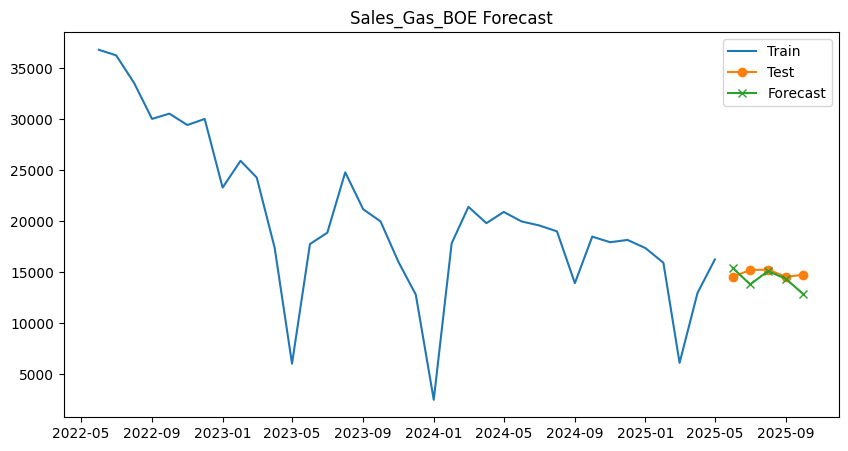

AttributeError: 'NoneType' object has no attribute 'get_forecast'

In [57]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings("ignore")

# --------------------- Load and Prepare Data ---------------------
prod_forecasting_df['Month-Year'] = pd.to_datetime(prod_forecasting_df['Month-Year'])
prod_forecasting_df = prod_forecasting_df.set_index('Month-Year').sort_index()

# Targets to forecast
targets = ['Sales_Gas_BOE', 'Sales_Condensate', 'gas processing_actual']

# Optional exogenous columns
exog_cols = []

# --------------------- Forecasting Function with Iteration ---------------------
def forecast_sarimax_best(df, target_col, exog_cols=None, steps=5):
    # Drop NaNs
    if exog_cols:
        cols_to_use = [target_col] + exog_cols
        data = df[cols_to_use].dropna()
        exog = data[exog_cols] if exog_cols else None
    else:
        data = df[[target_col]].dropna()
        exog = None

    y = data[target_col]

    if len(y) <= steps:
        print(f"Not enough data to forecast {target_col}")
        return None

    train_y = y[:-steps]
    test_y = y[-steps:]

    train_X = exog[:-steps] if exog is not None else None
    test_X = exog[-steps:] if exog is not None else None

    y_log_train = np.log(train_y)

    # --------------------- Grid Search for Best SARIMAX ---------------------
    p = q = range(0, 3)
    d = [1]
    P = Q = range(0, 3)
    D = [1]
    s = 3  # seasonal period

    best_rmse = np.inf
    best_order = None
    best_seasonal_order = None
    best_model = None

    for order in itertools.product(p, d, q):
        for seasonal in itertools.product(P, D, Q):
            seasonal_order = (*seasonal, s)
            try:
                model = SARIMAX(
                    y_log_train,
                    exog=train_X,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                model_fit = model.fit(disp=False)

                forecast_log = model_fit.get_forecast(
                    steps=len(test_y),
                    exog=test_X
                ).predicted_mean

                forecast = np.exp(forecast_log)
                rmse = np.sqrt(mean_squared_error(test_y, forecast))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_model = model_fit
            except:
                continue

    # Forecast using best model
    forecast_log = best_model.get_forecast(
        steps=len(test_y),
        exog=test_X
    ).predicted_mean
    forecast = np.exp(forecast_log)
    forecast.index = test_y.index

    # Metrics
    mae = mean_absolute_error(test_y, forecast)
    rmse = np.sqrt(mean_squared_error(test_y, forecast))
    mape = np.mean(np.abs((test_y - forecast) / test_y)) * 100
    smape = 100 * np.mean(np.abs(forecast - test_y) / ((np.abs(test_y) + np.abs(forecast)) / 2))

    print(f"--- {target_col} ---")
    print(f"Best Order           : {best_order}")
    print(f"Best Seasonal Order  : {best_seasonal_order}")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"sMAPE : {smape:.2f}%\n")

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(train_y.index, train_y, label='Train')
    plt.plot(test_y.index, test_y, label='Test', marker='o')
    plt.plot(forecast.index, forecast, label='Forecast', marker='x')
    plt.title(f"{target_col} Forecast")
    plt.legend()
    plt.show()

    return forecast, best_order, best_seasonal_order

# --------------------- Run Forecasts for All Targets ---------------------
forecast_results = {}
for target in targets:
    forecast_results[target] = forecast_sarimax_best(prod_forecasting_df, target)



--- Sales_Gas_BOE ---
Best Order          : (0, 1, 0)
Best Seasonal Order : (1, 1, 1, 3)
MAE   : 1827.00
RMSE  : 2318.42
MAPE  : 17.42%
sMAPE : 15.42%


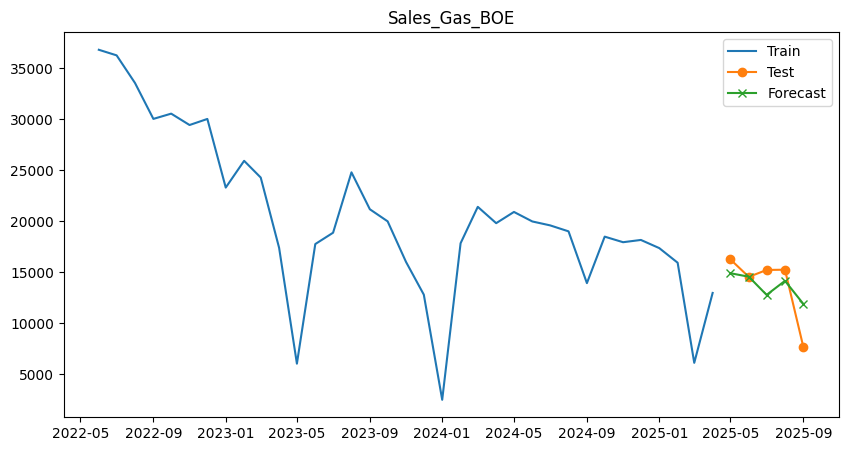

No suitable model found for Sales_Condensate

--- gas processing_actual ---
Best Order          : (0, 1, 1)
Best Seasonal Order : (0, 1, 1, 3)
MAE   : 138410701.12
RMSE  : 214044537.83
MAPE  : 143490.07%
sMAPE : 195.35%


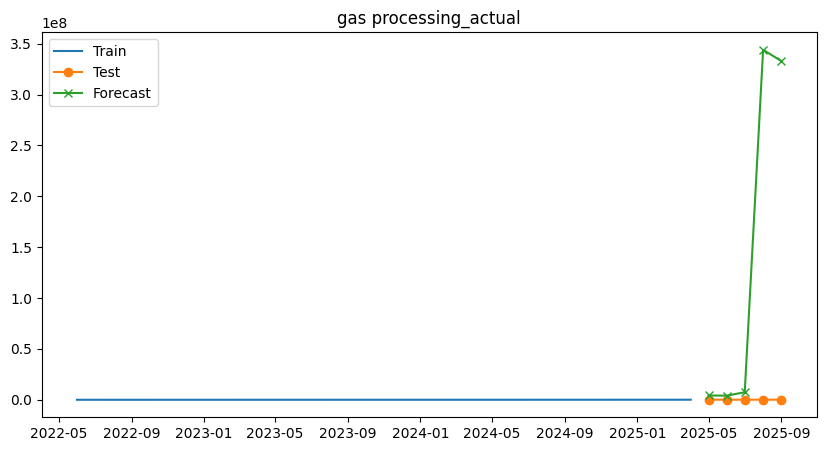

,Actual,Forecast
Month-Year,,
2025-05-01,16228.573272,14875.309233
2025-06-01,14517.856963,14535.467022
2025-07-01,15196.749269,12752.348327
2025-08-01,15222.342100,14130.742405
2025-09-01,7637.407133,11865.528504


In [76]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings("ignore")

# --------------------- Forecasting Function ---------------------
def forecast_sarimax_safe(df, target_col, exog_cols=None, steps=5, p_range=range(0,2), d_range=[1], q_range=range(0,2),
                          P_range=range(0,2), D_range=[1], Q_range=range(0,2), s=3):
    """
    Forecast a single target column using SARIMAX with NaN handling and parameter search.
    
    Returns a DataFrame with actual and forecasted values.
    """
    # Drop NaNs for target and exogenous columns
    if exog_cols:
        cols_to_use = [target_col] + exog_cols
        data = df[cols_to_use].dropna()
        exog = data[exog_cols]
    else:
        data = df[[target_col]].dropna()
        exog = None

    y = data[target_col]

    if len(y) <= steps:
        print(f"Not enough data to forecast {target_col}")
        return None

    # Train-test split
    train_y = y[:-steps]
    test_y = y[-steps:]

    train_X = exog[:-steps] if exog is not None else None
    test_X = exog[-steps:] if exog is not None else None

    # Log-transform for stability
    y_log_train = np.log(train_y)

    # --------------------- Parameter Search ---------------------
    best_rmse = np.inf
    best_model = None
    best_order = None
    best_seasonal = None

    for order in itertools.product(p_range, d_range, q_range):
        for seasonal in itertools.product(P_range, D_range, Q_range):
            seasonal_order = (*seasonal, s)
            try:
                model = SARIMAX(
                    y_log_train,
                    exog=train_X,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                model_fit = model.fit(disp=False)
                forecast_log = model_fit.get_forecast(steps=len(test_y), exog=test_X).predicted_mean
                forecast = np.exp(forecast_log)
                rmse = np.sqrt(mean_squared_error(test_y, forecast))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model_fit
                    best_order = order
                    best_seasonal = seasonal_order

            except:
                continue

    if best_model is None:
        print(f"No suitable model found for {target_col}")
        return None

    # --------------------- Forecast with Best Model ---------------------
    forecast_log = best_model.get_forecast(steps=len(test_y), exog=test_X).predicted_mean
    forecast = np.exp(forecast_log)
    forecast.index = test_y.index

    # Metrics
    mae = mean_absolute_error(test_y, forecast)
    rmse = np.sqrt(mean_squared_error(test_y, forecast))
    mape = np.mean(np.abs((test_y - forecast) / test_y)) * 100
    smape = 100 * np.mean(np.abs(forecast - test_y) / ((np.abs(test_y) + np.abs(forecast)) / 2))

    print(f"\n--- {target_col} ---")
    print(f"Best Order          : {best_order}")
    print(f"Best Seasonal Order : {best_seasonal}")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"sMAPE : {smape:.2f}%")

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(train_y.index, train_y, label='Train')
    plt.plot(test_y.index, test_y, label='Test', marker='o')
    plt.plot(forecast.index, forecast, label='Forecast', marker='x')
    plt.title(target_col)
    plt.legend()
    plt.show()

    # Combine actual and forecast
    result_df = pd.DataFrame({
        'Actual': test_y,
        'Forecast': forecast
    })

    return result_df

# --------------------- Run Forecasts for Multiple Targets ---------------------
targets = ['Sales_Gas_BOE', 'Sales_Condensate', 'gas processing_actual']
forecast_results = {}

for target in targets:
    forecast_results[target] = forecast_sarimax_safe(
        df=prod_forecasting_df,
        target_col=target,
        exog_cols=None,  # or specify exogenous columns
        steps=5
    )

# --------------------- Example: View Forecast vs Actual ---------------------
forecast_results['Sales_Gas_BOE']


In [33]:
gas_revenue.tail()

,Month-Year,Total Revenue,Gas Revenue,OPEX_Actual,Sales_Gas_BOE,Total_sujawal_sales_BOE,Revenue/BOE,Gas Revenue/BOE,Gas Revenue_FY_cumsum,Gas Revenue_lag2,Gas Revenue_roll3,Gas Revenue_QoQ_sum,Gas Revenue diff1
32,2025-02-01,2.918458e+08,99734822.0,7.831370e+07,15906.827516,16812.557516,17358.800963,6269.937981,1.184997e+09,155949407.0,416165322.0,381911757.0,-60746271.0
33,2025-03-01,2.920036e+08,121695842.0,2.886124e+07,6090.359484,6694.179484,43620.525705,19981.717387,1.306693e+09,160481093.0,381911757.0,381911757.0,21961020.0
34,2025-04-01,1.706794e+08,135687226.0,1.269152e+08,12943.565062,13547.385062,12598.696627,10482.987133,1.442381e+09,99734822.0,357117890.0,344548784.0,13991384.0
35,2025-05-01,2.823313e+08,112102594.0,1.004073e+08,16228.573272,17436.213272,16192.239171,6907.729479,1.554483e+09,121695842.0,369485662.0,344548784.0,-23584632.0
36,2025-06-01,2.655783e+08,96758964.0,7.150147e+07,14517.856963,15725.496963,16888.388047,6664.824171,1.651242e+09,135687226.0,344548784.0,344548784.0,-15343630.0


In [37]:
forecast

2025-07-01    8.930054e+07
2025-08-01    6.598327e+07
2025-09-01    6.224721e+07
2025-10-01    7.422747e+07
2025-11-01    7.376145e+07
2025-12-01    7.335493e+07
2026-01-01    7.578499e+07
2026-02-01    4.978651e+07
2026-03-01    6.086745e+07
2026-04-01    6.571022e+07
2026-05-01    5.653466e+07
2026-06-01    4.872715e+07
2026-07-01    4.760982e+07
2026-08-01    3.102647e+07
2026-09-01    3.347262e+07
2026-10-01    3.838158e+07
2026-11-01    3.796047e+07
2026-12-01    3.782012e+07
2027-01-01    3.906567e+07
2027-02-01    2.678795e+07
2027-03-01    3.277041e+07
2027-04-01    3.455383e+07
2027-05-01    3.063159e+07
2027-06-01    2.637633e+07
Freq: MS, Name: predicted_mean, dtype: float64

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Suppose last 12 months are test data
test = ts[-12:]
forecast = model_fit.get_forecast(steps=12)
pred = forecast.predicted_mean

# MAE
mae = mean_absolute_error(test, pred)

# RMSE
rmse = np.sqrt(mean_squared_error(test, pred))

# MAPE
mape = np.mean(np.abs((test - pred)/test)) * 100

# sMAPE
smape = 100 * np.mean(np.abs(pred - test) / ((np.abs(test) + np.abs(pred))/2))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")


MAE: 152972670.03
RMSE: 153295916.06
MAPE: nan%
sMAPE: nan%


Model Training

In [109]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Target column
target_col = 'Gas Revenue'

# Features
features_cols = gas_revenue_columns.copy()
features_cols.remove('Month-Year')
features_cols.remove(target_col)

X = gas_revenue[features_cols]
y = gas_revenue[target_col]

# Fill any remaining NaN
X = X.fillna(0)
y = y.fillna(0)

# Keep Month-Year separately
month_year = gas_revenue['Month-Year']


# -----------------------------
# 2) TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -----------------------------
# 3) SCALING
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4) TRAIN MODEL (LightGBM)
# -----------------------------
lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31
)

lgb_model.fit(X_train_scaled, y_train)

# -----------------------------
# 5) ACCURACY METRICS
# -----------------------------
y_pred_test = lgb_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1e-9))) * 100

print("\n=== MODEL ACCURACY ===")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

# -----------------------------
# 6) FORECAST FUTURE (2025-07 → 2026-06)
# -----------------------------

history = gas_revenue.copy()
future_months = pd.date_range(start="2025-07-01", end="2026-06-01", freq="MS")

future_predictions = []

for month in future_months:

    # build one row of features for the month
    row = {}

    for col in feature_cols:
        if "lag" in col:
            lag_n = int(col.split("lag")[1])
            row[col] = history[target_col].iloc[-lag_n]

        elif "roll" in col:
            w = int(col.split("roll")[1])
            row[col] = history[target_col].iloc[-w:].sum()

        elif "Month" in col:
            real_month = month.month
            row[col] = 1 if f"Month_{real_month}" == col else 0

        else:
            # static features (like FY, quarter, etc.)
            row[col] = history[col].iloc[-1]

    df_month = pd.DataFrame([row])

    # Ensure same column order as training
    df_month = df_month[feature_cols]

    # Scale
    df_scaled = scaler.transform(df_month)

    # Predict
    pred_value = lgb_model.predict(df_scaled)[0]

    # Store results
    future_predictions.append([month, pred_value])

    # Append prediction to history to maintain lag continuity
    new_row = history.iloc[-1:].copy()
    new_row["Month-Year"] = month
    new_row[target_col] = pred_value
    history = pd.concat([history, new_row], ignore_index=True)

# -----------------------------
# 7) FORECAST RESULTS
# -----------------------------
forecast_df = pd.DataFrame(
    future_predictions,
    columns=["Month-Year", "Gas Revenue Forecast"]
)

print("\n=== FORECAST RESULTS (2025-07 → 2026-06) ===")
print(forecast_df)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 29, number of used features: 0
[LightGBM] [Info] Start training from score 281822548.689655
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet 

C:\Users\uzubair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


KeyError: 'Sales_Condensate'

In [119]:
y_pred_test

array([2.81822549e+08, 2.81822549e+08, 2.81822549e+08, 2.81822549e+08,
       2.81822549e+08, 2.81822549e+08, 2.81822549e+08, 2.81822549e+08])

In [110]:
forecast_df

,Month-Year,Gas Revenue_Forecast
0,2023-07-01,3.306479e+08
1,2023-08-01,3.306479e+08
2,2023-09-01,3.306479e+08
3,2023-10-01,3.306479e+08
4,2023-11-01,3.306479e+08
5,2023-12-01,3.306479e+08
6,2024-01-01,3.306479e+08
7,2024-02-01,3.306479e+08
8,2024-03-01,3.306479e+08
9,2024-04-01,3.306479e+08


In [97]:
train_size = len(X_scaled) - 24

X_train = X_scaled[:train_size]
y_train = y[:train_size]

X_test = X_scaled[train_size:]
y_test = y[train_size:]
month_test = month_year[train_size:]


In [98]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

lgb_model.fit(X_train, y_train)


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 13, number of used features: 0
[LightGBM] [Info] Start training from score 330647947.692308
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet 

LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=500,
              random_state=42)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------

# 1. Preprocessing & Feature Engineering

# -----------------------------

revenue_df['Month-Year'] = pd.to_datetime(revenue_df['Month-Year'])
revenue_df = revenue_df.sort_values('Month-Year').reset_index(drop=True)

# Fiscal Year

revenue_df['FY'] = revenue_df['Month-Year'].map(lambda d: d.year + 1 if d.month >= 7 else d.year)

# Month cyclic features

revenue_df['Month'] = revenue_df['Month-Year'].dt.month
revenue_df['Month_sin'] = np.sin(2 * np.pi * revenue_df['Month'] / 12)
revenue_df['Month_cos'] = np.cos(2 * np.pi * revenue_df['Month'] / 12)

# Quarter and trend

revenue_df['Quarter'] = revenue_df['Month-Year'].dt.quarter
revenue_df['Month_Number'] = np.arange(len(revenue_df)) + 1  # trend

# KPIs

kpi_cols = ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']

# FY cumulative, lag, rolling, QoQ

for col in kpi_cols:
    revenue_df[f'{col}_FY_cumsum'] = revenue_df.groupby('FY')[col].cumsum()
for lag in [1,2,3]:
    revenue_df[f'{col}_lag{lag}'] = revenue_df[col].shift(lag)
for w in [2,3,6]:
    revenue_df[f'{col}_roll{w}'] = revenue_df[col].rolling(window=w).sum()
# Add a quarter number based on month sequence
revenue_df['Quarter_Number'] = ((revenue_df['Month_Number'] - 1) // 3) + 1

# Then group by Quarter_Number and compute sum
revenue_df[f'{col}_QoQ_sum'] = revenue_df.groupby('Quarter_Number')[col].transform('sum')


# Fill NaNs

revenue_df = revenue_df.fillna(0)

# -----------------------------

# 2. Feature selection

# -----------------------------

feature_cols = ['Total Revenue','OPEX_Actual','Sales_Gas_BOE','Sales_Condensate','gas processing_actual',
'Total_sujawal_sales_BOE','Sujjawal and gas processing','Revenue/BOE','Gas Revenue/BOE',
'Condensate/BOE','OPEX/BOE','Month_sin','Month_cos','Month_Number']

# Add KPI-derived features

for col in kpi_cols:
    feature_cols += [f'{col}_FY_cumsum'] + [f'{col}_lag{lag}' for lag in [1,2,3]] + [f'{col}_roll{w}' for w in [2,3,6]] + [f'{col}_QoQ_sum']

X = revenue_df[feature_cols]
y = revenue_df[kpi_cols]
month_year = revenue_df['Month-Year']

# -----------------------------

# 3. Scale features

# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------

# 4. Train/Test Split

# -----------------------------

train_size = len(X_scaled) - 24
X_train = X_scaled[:train_size]
y_train = y[:train_size]
X_test = X_scaled[train_size:]
y_test = y[train_size:]
month_test = month_year[train_size:]

# -----------------------------

# 5. Train Model

# -----------------------------

lgb_model = MultiOutputRegressor(lgb.LGBMRegressor(
n_estimators=500,
learning_rate=0.05,
max_depth=5,
random_state=42
))
lgb_model.fit(X_train, y_train)

# -----------------------------

# 6. Evaluate on test

# -----------------------------

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/np.where(y_true==0, np.nan, y_true)))*100

y_pred_test = pd.DataFrame(lgb_model.predict(X_test), index=month_test, columns=kpi_cols)
for col in kpi_cols:
    mae = mean_absolute_error(y_test[col], y_pred_test[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred_test[col]))
    mape_val = mape(y_test[col], y_pred_test[col])
    print(f'{col} --> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape_val:.2f}%')

# -----------------------------

# 7. Iterative forecast next 24 months

# -----------------------------

# -----------------------------
# 7. Iterative forecast next 24 months
# -----------------------------

history = revenue_df.copy()
future_months = pd.date_range(start='2025-07-01', periods=24, freq='MS')
future_preds = []

for i, month in enumerate(future_months):
    month_features = {}

    # Base features from last available row
    base_cols = ['Total Revenue','OPEX_Actual','Sales_Gas_BOE','Sales_Condensate',
                 'gas processing_actual','Total_sujawal_sales_BOE','Sujjawal and gas processing',
                 'Revenue/BOE','Gas Revenue/BOE','Condensate/BOE','OPEX/BOE']
    for f in base_cols:
        month_features[f] = history[f].iloc[-1]

    # Lag, rolling, FY cumulative, QoQ for each KPI
    for col in kpi_cols:
        month_features[f'{col}_lag1'] = history[col].iloc[-1] if len(history) >= 1 else 0
        month_features[f'{col}_lag2'] = history[col].iloc[-2] if len(history) >= 2 else 0
        month_features[f'{col}_lag3'] = history[col].iloc[-3] if len(history) >= 3 else 0
        month_features[f'{col}_roll2'] = history[col].iloc[-2:].sum() if len(history) >= 2 else history[col].sum()
        month_features[f'{col}_roll3'] = history[col].iloc[-3:].sum() if len(history) >= 3 else history[col].sum()
        month_features[f'{col}_roll6'] = history[col].iloc[-6:].sum() if len(history) >= 6 else history[col].sum()
        month_features[f'{col}_FY_cumsum'] = history[col].iloc[-12:].sum() if len(history) >= 12 else history[col].sum()
        month_features[f'{col}_QoQ_sum'] = history[col].iloc[-3:].sum() if len(history) >= 3 else history[col].sum()

    # Month cyclic and trend
    month_features['Month_sin'] = np.sin(2 * np.pi * month.month / 12)
    month_features['Month_cos'] = np.cos(2 * np.pi * month.month / 12)
    month_features['Month_Number'] = history['Month_Number'].iloc[-1] + 1

    # Convert to DataFrame
    month_df = pd.DataFrame([month_features])

    # Scale and predict
    month_scaled = scaler.transform(month_df[feature_cols])
    y_pred_month = lgb_model.predict(month_scaled)

    # Save forecast
    future_preds.append([month] + list(y_pred_month.flatten()))

    # Append predicted row to history for next iteration
    new_row = month_features.copy()
    new_row['Month-Year'] = month
    for j, col in enumerate(kpi_cols):
        new_row[col] = y_pred_month[0][j]
    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

# Build forecast DataFrame
forecast_df = pd.DataFrame(future_preds, columns=['Month-Year'] + kpi_cols)
forecast_df['Month-Year'] = pd.to_datetime(forecast_df['Month-Year'])
print(forecast_df)


KeyError: "['Gas Revenue_roll6', 'Condensate Revenue_roll6'] not in index"

In [104]:
history = gas_revenue.copy()
future_months = pd.date_range(start='2025-07-01', periods=24, freq='MS')
future_preds = []

for month in future_months:
    # Prepare features for this month
    month_features = {}
    
    # Use previous values for lag/roll/QoQ
    month_features['Total Revenue'] = history['Total Revenue'].iloc[-1]
    month_features['OPEX_Actual'] = history['OPEX_Actual'].iloc[-1]
    month_features['Sales_Gas_BOE'] = history['Sales_Gas_BOE'].iloc[-1]
    month_features['Total_sujawal_sales_BOE'] = history['Total_sujawal_sales_BOE'].iloc[-1]
    month_features['Revenue/BOE'] = history['Revenue/BOE'].iloc[-1]
    month_features['Gas Revenue/BOE'] = history['Gas Revenue/BOE'].iloc[-1]
    
    # Lag features
    month_features['Gas Revenue_lag2'] = history['Gas Revenue'].iloc[-2] if len(history) >= 2 else 0
    
    # Rolling sums
    month_features['Gas Revenue_roll3'] = history['Gas Revenue'].iloc[-3:].sum() if len(history) >= 3 else 0
    
    # FY cumulative
    month_features['Gas Revenue_FY_cumsum'] = history['Gas Revenue'].iloc[-12:].sum()  # Approx FY
    
    # QoQ sum
    month_features['Gas Revenue_QoQ_sum'] = history['Gas Revenue'].iloc[-3:].sum()  # last quarter
    
    # Convert to DataFrame
    month_df = pd.DataFrame([month_features])
    
    # Ensure all columns are present
    for c in feature_cols:
        if c not in month_df.columns:
            month_df[c] = 0

    # Reorder columns to match scaler
    month_df = month_df[feature_cols]

    # Now scale
    month_scaled = scaler.transform(month_df)

    
    # Predict
    y_pred_month = lgb_model.predict(month_scaled)
    
    # Store
    future_preds.append([month] + [y_pred_month[0]])
    
    # Append predicted row to history for next month lag calculation
    new_row = pd.DataFrame({
        'Month-Year': [month],
        'Total Revenue': [month_features['Total Revenue']],
        'OPEX_Actual': [month_features['OPEX_Actual']],
        'Sales_Gas_BOE': [month_features['Sales_Gas_BOE']],
        'Total_sujawal_sales_BOE': [month_features['Total_sujawal_sales_BOE']],
        'Revenue/BOE': [month_features['Revenue/BOE']],
        'Gas Revenue/BOE': [month_features['Gas Revenue/BOE']],
        'Gas Revenue': [y_pred_month[0]],
        'Gas Revenue_FY_cumsum': [month_features['Gas Revenue_FY_cumsum']],
        'Gas Revenue_lag2': [month_features['Gas Revenue_lag2']],
        'Gas Revenue_roll3': [month_features['Gas Revenue_roll3']],
        'Gas Revenue_QoQ_sum': [month_features['Gas Revenue_QoQ_sum']]
    })
    history = pd.concat([history, new_row], ignore_index=True)

# Forecast DataFrame
forecast_df = pd.DataFrame(future_preds, columns=['Month-Year','Gas Revenue_Forecast'])
forecast_df['Month-Year'] = pd.to_datetime(forecast_df['Month-Year'])

print(forecast_df)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Condensate Revenue_FY_cumsum
- Condensate Revenue_QoQ_sum
- Condensate Revenue_lag1
- Condensate Revenue_lag2
- Condensate Revenue_lag3
- ...


In [35]:
from sklearn.preprocessing import StandardScaler

revenue_df_clean = revenue_df.fillna(0) # removes rows where any feature is NaN
features = revenue_df_clean.drop(columns=['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue'])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

from sklearn.decomposition import PCA

pca = PCA()
pca_components = pca.fit_transform(features_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print(explained_variance.cumsum())  # cumulative variance explained


[0.23804317 0.36262399 0.44745078 0.51197927 0.57244834 0.63072537
 0.67309384 0.71525251 0.74782994 0.7800005  0.8103214  0.83858298
 0.86631856 0.89034498 0.91146734 0.9288136  0.94381473 0.95725816
 0.96689315 0.97536941 0.98184937 0.98715241 0.9918691  0.99524114
 0.9970864  0.99828035 0.99903048 0.99945559 0.99969706 0.99984411
 0.99992786 0.99997664 0.99999359 0.99999832 0.99999981 1.
 1.        ]


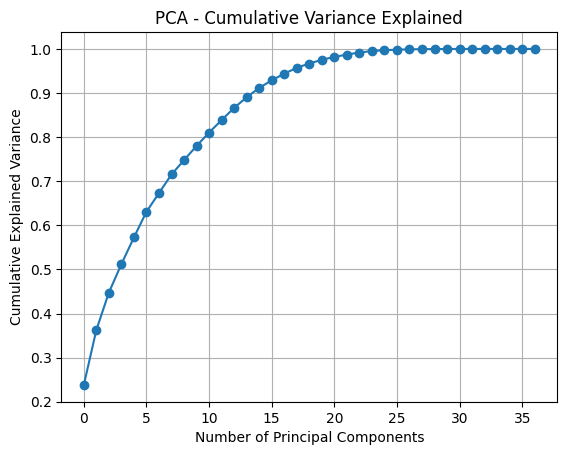

In [36]:
import matplotlib.pyplot as plt

plt.plot(explained_variance.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Variance Explained')
plt.grid(True)
plt.show()


# Applying PCA for top 15 components

In [37]:
from sklearn.decomposition import PCA

# Keep first 15 principal components
pca = PCA(n_components=15)
pca_components_15 = pca.fit_transform(features_scaled)

pca_df = pd.DataFrame(pca_components_15, 
                      index=revenue_df_clean.index,  # keep original Month-Year index
                      columns=[f'PC{i+1}' for i in range(15)])

targets = revenue_df_clean[['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']]
ml_data = pd.concat([pca_df, targets], axis=1)

train = ml_data.iloc[:-24]
test = ml_data.iloc[-24:]
X_train = train.drop(columns=['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue'])
y_train = train[['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']]
X_test = test.drop(columns=['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue'])
y_test = test[['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']]


In [52]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
Month-Year,,,,,,,,,,,,,,,
2022-06-01,1.246030,-5.688187,0.784307,-0.229948,-2.680149,-3.429655,-2.381887,-1.131189,0.670768,1.833752,-0.828478,-0.492618,-0.164833,-0.794010,-0.631269
2022-07-01,-1.366340,-4.320183,-1.475387,2.798856,-0.961494,-3.464426,-1.322105,4.492654,0.267446,-1.047132,0.642262,-0.134573,-0.681559,-0.132349,-0.741410
2022-08-01,-2.375935,-2.504141,-2.669127,1.852760,1.169308,3.041811,0.080536,1.062440,-2.323615,2.328344,-1.668984,-1.819879,0.771398,-0.198414,-0.826880
2022-09-01,-1.920568,-0.795297,-2.367721,0.362230,0.416999,1.325672,1.937394,-0.771293,3.543590,1.647577,1.566433,-0.171420,-0.795354,-0.048488,-0.374723
2022-10-01,-2.176089,-0.695525,-1.983517,-0.637469,-0.757116,1.179460,-0.089243,0.108745,1.499753,-2.232823,-2.178898,1.595538,2.079969,0.426760,-0.715784
2022-11-01,-2.073329,-0.949412,-2.165462,0.688141,-0.206131,-0.116483,1.698873,-0.414654,-1.505456,1.140116,1.059685,2.520831,-0.382311,-0.028774,-1.199160
2022-12-01,-2.364847,-0.418202,-1.693772,-0.420746,0.120011,0.371503,-0.363565,-0.682358,-0.010463,-0.488474,-0.345530,-0.560220,-1.487747,2.963902,-0.780399
2023-01-01,-1.872302,0.983052,-1.207902,-0.500774,-0.437291,-0.221118,-0.239001,0.504884,0.633979,1.839875,-0.452391,0.656134,1.130860,1.492864,0.958312
2023-02-01,-1.995334,0.410013,-2.165599,-0.080679,0.355931,-0.463217,-0.493448,-0.844613,-0.621463,-0.397694,2.116606,-0.441543,2.035942,0.724900,0.089859


In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Preprocessing & Feature Engineering
# -----------------------------
# Ensure Month-Year is datetime and sort
revenue_df['Month-Year'] = pd.to_datetime(revenue_df['Month-Year'])
revenue_df = revenue_df.sort_values('Month-Year').reset_index(drop=True)

# Fiscal year cumulative sums (July-June)
def get_fy(date):
    return date.year + 1 if date.month >= 7 else date.year

revenue_df['FY'] = revenue_df['Month-Year'].map(get_fy)

kpi_cols = ['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue']
for col in kpi_cols:
    revenue_df[f'{col}_FY_cumsum'] = revenue_df.groupby('FY')[col].cumsum()

# Lag features and rolling sums
lags = [1,2,3]
roll_windows = [2,3]

for col in kpi_cols:
    for lag in lags:
        revenue_df[f'{col}_lag{lag}'] = revenue_df[col].shift(lag)
    for w in roll_windows:
        revenue_df[f'{col}_roll{w}'] = revenue_df[col].rolling(window=w).sum()

# Seasonal features (month dummies)
revenue_df['Month'] = revenue_df['Month-Year'].dt.month
revenue_df = pd.get_dummies(revenue_df, columns=['Month'], prefix='M')

# Replace NaNs with 0
revenue_df = revenue_df.fillna(0)

# -----------------------------
# 2. Prepare Features and Targets
# -----------------------------
features = revenue_df.drop(columns=kpi_cols)
targets = revenue_df[kpi_cols]

# Keep Month-Year separately for reference
month_year = features['Month-Year'].values
features_numeric = features.select_dtypes(include=[np.number])  # Only numeric for scaling

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_numeric)

# PCA - keep 15 components
pca = PCA(n_components=15)
features_pca = pca.fit_transform(features_scaled)

# Convert PCA components to DataFrame and attach Month-Year
features_pca_df = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(15)])
features_pca_df['Month-Year'] = month_year

# Combine with targets
ml_data = pd.concat([features_pca_df, targets.reset_index(drop=True)], axis=1)

# -----------------------------
# 3. Train/Test Split (last 24 months as test)
# -----------------------------
train = ml_data.iloc[:-24]
test = ml_data.iloc[-24:]

X_train = train.drop(columns=['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue', 'Month-Year'])
y_train = train[kpi_cols]
X_test = test.drop(columns=['Gas Revenue', 'Condensate Revenue', 'Gas Processing Revenue', 'Month-Year'])
y_test = test[kpi_cols]

# -----------------------------
# 4. Train Model - LightGBM
# -----------------------------
lgb_model = MultiOutputRegressor(lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
))
lgb_model.fit(X_train, y_train)

# -----------------------------
# 5. Predictions
# -----------------------------
y_pred = pd.DataFrame(lgb_model.predict(X_test), 
                      index=test['Month-Year'], 
                      columns=y_test.columns)

# -----------------------------
# 6. Evaluate Accuracy
# -----------------------------
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true)) * 100

def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
    ) * 100


for col in kpi_cols:
    mae = mean_absolute_error(y_test[col], y_pred[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[col]))
    mape_val = mape(y_test[col], y_pred[col])
    smape_val = smape(y_test[col], y_pred[col])

    print(f'{col} --> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape_val:.2f}%, sMAPE: {smape_val:.2f}%')



[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 13, number of used features: 0
[LightGBM] [Info] Start training from score 330647947.692308
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet 

C:\Users\uzubair\AppData\Local\Temp\ipykernel_156320\2149968034.py:101: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  return np.mean(np.abs((y_true - y_pred)/y_true)) * 100
C:\Users\uzubair\AppData\Local\Temp\ipykernel_156320\2149968034.py:105: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
C:\Users\uzubair\AppData\Local\Temp\ipykernel_156320\2149968034.py:101: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  return np.mean(np.abs((y_true - y_pred)/y_true)) * 100
C:\Users\uzubair\AppData\Local\Temp\ipykernel_156320\2149968034.py:105: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  2 * np.abs(

In [48]:
import pandas as pd

# Last available Month-Year in your dataset
last_month = revenue_df['Month-Year'].max()

# Generate future 12 months (July 2025 - June 2026)
future_months = pd.date_range(start='2025-07-01', end='2026-06-01', freq='MS')

# Create empty DataFrame
future_df = pd.DataFrame({'Month-Year': future_months})


In [50]:
import pandas as pd
import numpy as np

# Last available data
history = revenue_df.copy()
future_months = pd.date_range(start='2025-07-01', end='2026-06-01', freq='MS')

future_preds = []

for month in future_months:
    # Prepare features for this month
    month_features = {}

    # Fiscal year
    month_features['FY'] =  month.year + 1 if month.month >= 7 else month.year
    month_features['Month'] = month.month

    # Lag features
    for col in ['Gas Revenue', 'Condensate Revenue']:
        for lag in [1,2,3]:
            month_features[f'{col}_lag{lag}'] = history[col].iloc[-lag] if len(history) >= lag else 0
        # Rolling sums
        for w in [2,3]:
            month_features[f'{col}_roll{w}'] = history[col].iloc[-w:].sum() if len(history) >= w else 0

    # Convert to DataFrame
    month_df = pd.DataFrame([month_features])

    # Month dummies
    month_df = pd.get_dummies(month_df, columns=['Month'], prefix='M')

    # Align columns with training set
    missing_cols = set(X_train.columns) - set(month_df.columns)
    for c in missing_cols:
        month_df[c] = 0
    month_df = month_df[X_train.columns]

    # Scale numeric features
    month_scaled = scaler.transform(month_df)

    # Predict
    y_pred_month = lgb_model.predict(month_scaled)

    # Append predictions
    future_preds.append([month] + list(y_pred_month.flatten()[:2]))  # Gas + Condensate

    # Append predicted row to history for next month lag calculation
    new_row = pd.DataFrame({
        'Month-Year': [month],
        'Gas Revenue': [y_pred_month[0][0]],
        'Condensate Revenue': [y_pred_month[0][1]],
    })
    history = pd.concat([history, new_row], ignore_index=True)

# Build forecast DataFrame
forecast_df = pd.DataFrame(future_preds, columns=['Month-Year', 'Gas Revenue', 'Condensate Revenue'])
forecast_df['Month-Year'] = pd.to_datetime(forecast_df['Month-Year'])

print(forecast_df)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- PC1
- PC10
- PC11
- PC12
- PC13
- ...
Feature names seen at fit time, yet now missing:
- Condensate Revenue_FY_cumsum
- Condensate Revenue_lag1
- Condensate Revenue_lag2
- Condensate Revenue_lag3
- Condensate Revenue_roll2
- ...
